# Phase 4 — CNN-Transformer Hybrid Model

### Importing Libraries

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os, random, numpy as np
os.environ["PYTHONHASHSEED"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"       
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"       
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import tensorflow as tf
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , regularizers
from tensorflow.keras.optimizers import Adam 
from collections import Counter
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

### Loading the Dataset

In [2]:
# loading data
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# takeing a peak at data 
display(train_df.head())


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p35,p36,p37,p38,p39,p40,p41,p42,turn,label_move_col
0,0,1,-1,1,-1,0,1,0,1,-1,...,0,0,0,0,0,0,0,0,1,1
1,0,-1,-1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,-1,1
2,0,1,-1,1,0,0,1,0,0,-1,...,0,0,0,0,0,0,0,0,-1,2
3,1,0,0,0,-1,1,1,-1,0,0,...,0,0,0,0,0,0,0,0,-1,3
4,1,1,-1,-1,-1,1,-1,1,0,0,...,1,-1,0,0,0,0,0,1,-1,4


### Preprocessing: Convert Board DataFrame to CNN Input

Each Connect Four position is reshaped from the flattened columns (`p1`–`p42`) into a 6×7 board. 

The board values are multiplied by the player's turn (`turn` column) to align the perspective,  
so that the model always views the board from the current player's point of view.  
This ensures that the same board layout looks identical to the model regardless of whose turn it is.


After that the board is split into two channels:  
- one channel for the current player's pieces  
- one channel for the opponent's pieces  

Together, these channels provide a structured representation of the board for the model to analyze.

In [3]:
P_COLS = [f"p{i}" for i in range(1, 43)]  # p1..p42

def build_cnn_features(df):
    
    boards = df[P_COLS].to_numpy(dtype=np.int8).reshape(-1, 6, 7)      # (N,6,7)
    turns  = df["turn"].to_numpy(dtype=np.int8).reshape(-1, 1, 1)      # (N,1,1)
    boards = boards * turns                                            # normalize POV

    cur = (boards == 1).astype(np.float32)     # current player's discs
    opp = (boards == -1).astype(np.float32)    # opponent's discs
    X = np.stack([cur, opp], axis=-1)          # (N,6,7,2)

    y = None
    if  "label_move_col" in df.columns:
        y = df["label_move_col"].to_numpy(dtype=np.int64)
    return X, y

In [4]:
X_train, y_train = build_cnn_features(train_df)
X_val,   y_val   = build_cnn_features(val_df)
X_test,  _       = build_cnn_features(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)


X_train: (49993, 6, 7, 2) y_train: (49993,)
X_val:   (10774, 6, 7, 2) y_val:   (10774,)
X_test:  (10868, 6, 7, 2)


### CNN-Transformer Model Design

In [ ]:
# ========= Transformer block definition =========
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6) #nomalize
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # Self-attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [ ]:
embed_dim = 64      # must match last Conv2D filters
num_heads = 4
ff_dim = 128        # size of feed-forward inside transformer
lambdaa = 5e-5     # L2 strength 
drop = 0.20   # dropout rate
num_classes = 7

# convert to one-hot for label smoothing:
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)


model = keras.Sequential([
    layers.Input(shape=(6, 7, 2)),

    # Conv Block 1 
    layers.Conv2D(64, (3,3), padding="same", kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Conv Block 2 
    layers.Conv2D(64, (3,3), padding="same", kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # Conv Block 3
    layers.Conv2D(64, (3,3), padding="same", kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),

    # CNN → sequence for Transformer 
    layers.Reshape((6*7, embed_dim)),

    # Transformer encoder
    TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, rate=drop),

    # Pool over 42 positions → (64,)
    layers.GlobalAveragePooling1D(),

    # Dense head
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(lambdaa)),
    layers.Dropout(drop),

    # Output layer
    layers.Dense(num_classes, activation="softmax", name="policy"),
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 6, 7, 64)          1216      
                                                                 
 batch_normalization_3 (Batc  (None, 6, 7, 64)         256       
 hNormalization)                                                 
                                                                 
 re_lu_3 (ReLU)              (None, 6, 7, 64)          0         
                                                                 
 conv2d_4 (Conv2D)           (None, 6, 7, 64)          36928     
                                                                 
 batch_normalization_4 (Batc  (None, 6, 7, 64)         256       
 hNormalization)                                                 
                                                                 
 re_lu_4 (ReLU)              (None, 6, 7, 64)         

In [11]:
lr = 1e-3     # base learning rate
opt = keras.optimizers.Adam(learning_rate=lr)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.02)

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=["accuracy"]
)


callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=70,
    batch_size=512,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/70
98/98 - 34s - loss: 1.6755 - accuracy: 0.3782 - val_loss: 2.2766 - val_accuracy: 0.3674 - lr: 0.0010 - 34s/epoch - 352ms/step
Epoch 2/70
98/98 - 37s - loss: 1.3684 - accuracy: 0.5021 - val_loss: 2.2830 - val_accuracy: 0.1508 - lr: 0.0010 - 37s/epoch - 375ms/step
Epoch 3/70
98/98 - 38s - loss: 1.2266 - accuracy: 0.5644 - val_loss: 2.0548 - val_accuracy: 0.2849 - lr: 0.0010 - 38s/epoch - 391ms/step
Epoch 4/70
98/98 - 38s - loss: 1.1540 - accuracy: 0.5936 - val_loss: 1.3691 - val_accuracy: 0.5248 - lr: 0.0010 - 38s/epoch - 391ms/step
Epoch 5/70
98/98 - 39s - loss: 1.1095 - accuracy: 0.6098 - val_loss: 1.1818 - val_accuracy: 0.5907 - lr: 0.0010 - 39s/epoch - 393ms/step
Epoch 6/70
98/98 - 38s - loss: 1.0652 - accuracy: 0.6250 - val_loss: 1.1242 - val_accuracy: 0.6063 - lr: 0.0010 - 38s/epoch - 392ms/step
Epoch 7/70
98/98 - 38s - loss: 1.0329 - accuracy: 0.6372 - val_loss: 1.1087 - val_accuracy: 0.6151 - lr: 0.0010 - 38s/epoch - 392ms/step
Epoch 8/70
98/98 - 39s - loss: 0.9975 - a

In [12]:
# predict on validation data
y_val_pred = model.predict(X_val)
y_val_pred = y_val_pred.argmax(axis=1)

# Extract final metrics from history
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Training accuracy:", final_train_acc)
print("Training loss:", final_train_loss)
print("Validation accuracy:", final_val_acc)
print("Validation loss:", final_val_loss)

337/337 [==============================] - 4s 11ms/step
Training accuracy: 0.8117136359214783
Training loss: 0.6029700040817261
Validation accuracy: 0.6242806911468506
Validation loss: 1.2629324197769165


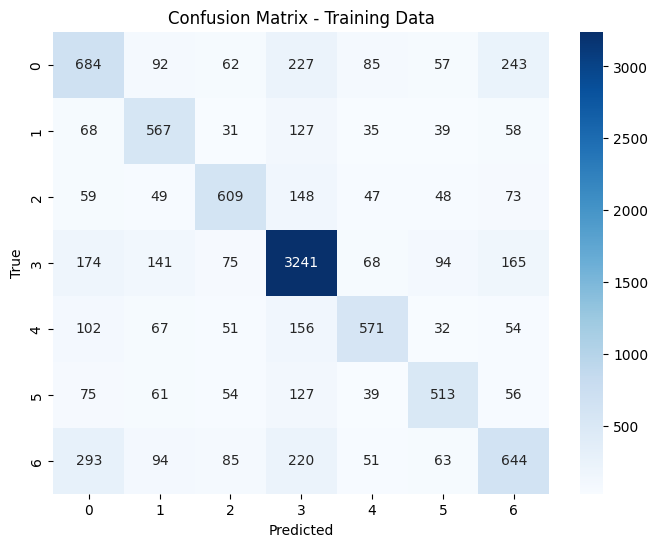

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Training Data")
plt.show()

In [14]:
# predict on test data
y_test_pred = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred , axis=1).astype(int)
Prediction = pd.DataFrame({"id": range( 1 , len(y_test_pred) +1 ), "label_move_col" : y_test_pred })
Prediction.to_csv("CNN-Transformer_prediction.csv" , index = False)

340/340 [==============================] - 4s 10ms/step
